In [140]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=200, n_features=2, n_informative=1, n_redundant=0,
                         n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=20)

In [141]:
X.shape

(200, 2)

In [142]:
import matplotlib.pyplot as plt

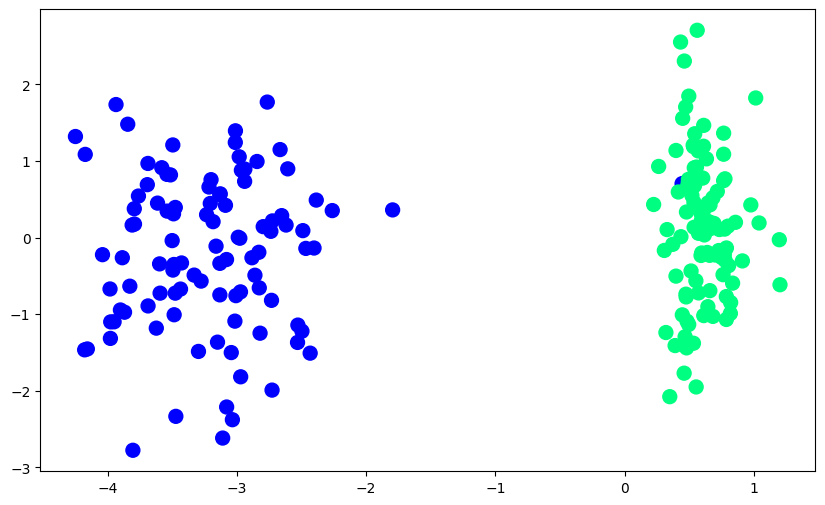

In [143]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [144]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None, solver='sag').fit(X,y)

C:\DataScience\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [145]:
print('coef_: ', lor.coef_)
print('intercept_: ',lor.intercept_)

coef_:  [[ 5.32372697 -0.55316731]]
intercept_:  [1.95501041]


In [146]:
m1 = -(lor.coef_[0][0]/ lor.coef_[0][1])
b1 = -(lor.intercept_/ lor.coef_[0][1])

In [147]:
X_input = np.linspace(-3,3, 200)
y_input = m1*X_input + b1

In [148]:
def gd(X,y):
    X = np.insert(X,0,1, axis=1)
    weight = np.ones(X.shape[1])
    lr = 0.5
    epochs = 10000

    for i in range(epochs):
        y_hat = sigmoid(np.dot(X, weight))
        weight += lr*(np.dot((y-y_hat), X)/ X.shape[0])

    return weight[1:], weight[0]
        

In [149]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [150]:
coef_, intercept_ = gd(X,y)

In [151]:
print(coef_)
print(intercept_)

[ 5.12602113 -0.55417188]
2.0532454688040054


In [152]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [153]:
X_input1 = np.linspace(-3,3,200)
y_input1 = m*X_input1 + b

(-3.0, 2.0)

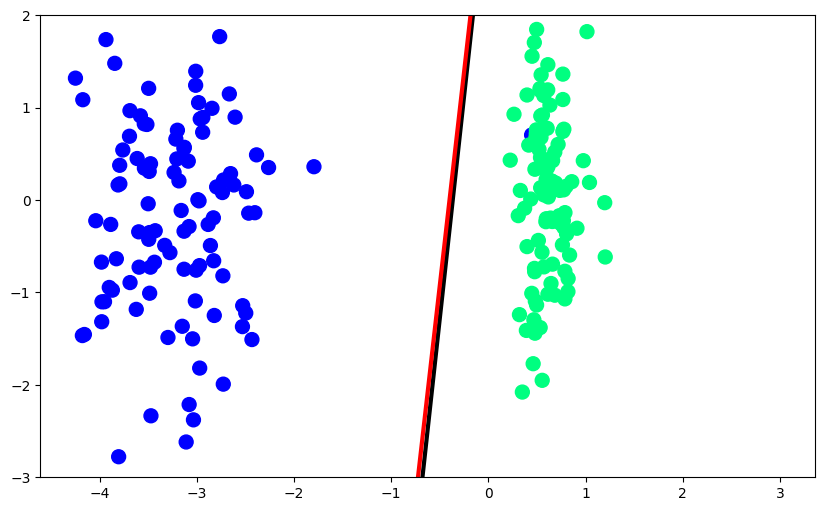

In [154]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s=100)
plt.plot(X_input, y_input, c='black', linewidth = 3)
plt.plot(X_input1, y_input1, c='red', linewidth = 3)
plt.ylim(-3,2)